In [27]:
import os
import pickle
import sys
import threading
from collections import Counter
from copy import deepcopy
from pprint import pprint

# import pandas as pd
import folium
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
from scipy import ndimage
from skimage.feature import peak_local_max  # noqa: F401

parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from utils.configure_scienceplots import configure_scienceplots  # noqa: E402
from utils.constants import (  # noqa: E402
    FIGURES_DIR,
    RAW_DATA_DIR,
)
from utils.load_data import load_processed_original_data  # noqa: E402

MAPS_FIGURES_DIR = FIGURES_DIR / "maps"
MAPS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

configure_scienceplots()

mutex = threading.Lock()

In [3]:
gdf = load_processed_original_data(as_geopandas=True, parse_dates=True)
gdf.head()

,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA,DIA_SEMANA_OCURRENCIA,GRAVEDAD,CLASE,LOCALIDAD,latitude,longitude,geometry
0,646545,A00410124,306211,2008-09-05 12:50:00,5,CON HERIDOS,ATROPELLO,TEUSAQUILLO,4.655402,-74.101700,POINT (-74.1017 4.6554)
1,563782,839933000,291565,2008-05-20 23:40:00,2,SOLO DANOS,CHOQUE,ENGATIVA,4.689417,-74.109351,POINT (-74.10935 4.68942)
2,4398952,A000038718,4398952,2014-12-04 17:30:00,4,SOLO DANOS,CHOQUE,ENGATIVA,4.689750,-74.109016,POINT (-74.10902 4.68975)
3,1612,726750500,30243,2007-06-29 19:30:00,5,CON HERIDOS,ATROPELLO,PUENTE ARANDA,4.615129,-74.108947,POINT (-74.10895 4.61513)
4,569692,840564600,297475,2008-07-21 07:30:00,1,SOLO DANOS,CHOQUE,TEUSAQUILLO,4.646696,-74.108792,POINT (-74.10879 4.6467)


## Accidents on the map

I'm only doing this to get an idea of how the points are distributed. But I have two incredible ideas that can be drawn from this:

1. Find the edges (streets, roads, avenues, etc.) where most accidents occur, and for that I can use other resources such as osmnx. Maybe count the number of accidents for each of the edges, who knows...

2. In the area of computer vision, sometimes you get the points and to try to clean them up, I can try to dilate them, and then for those areas that are formed, take the peak_local_max. That might be enough, but perhaps it would be good for each of those areas to have an attribute related to the point count that was made. The problem with this approach is choosing good thresholds and kernels, but that's trial and error.

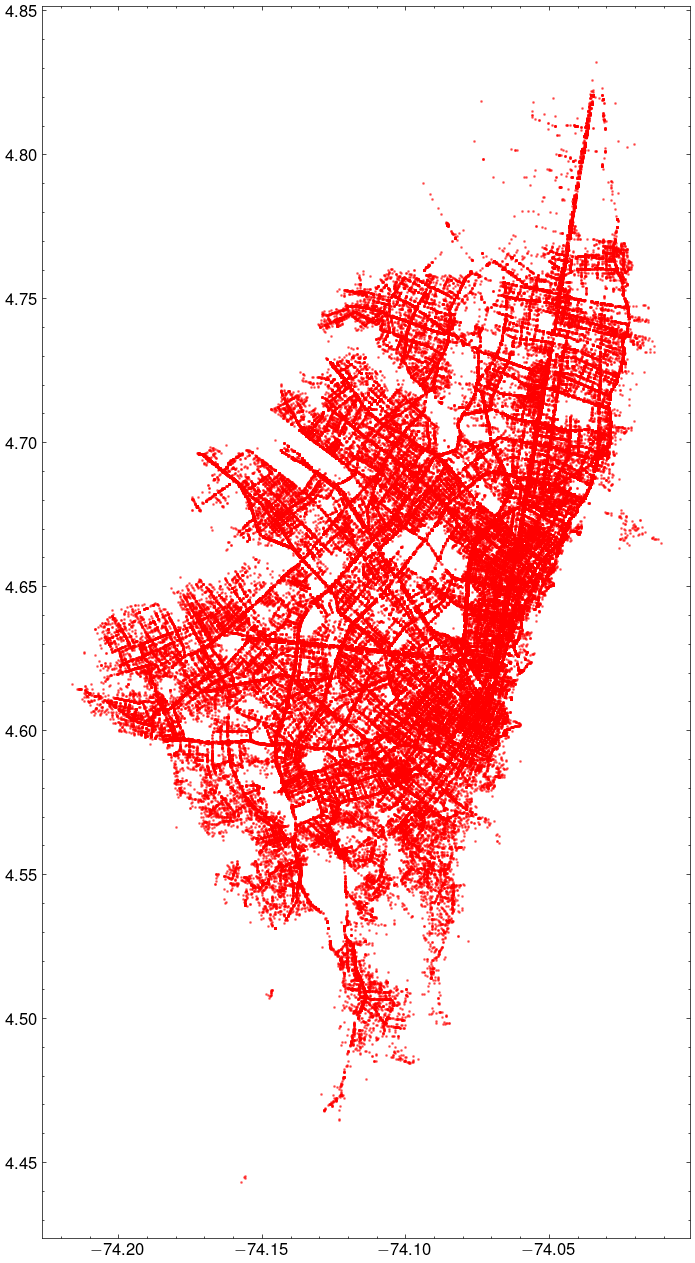

In [4]:
gdf.plot(figsize=(10, 16), markersize=1, alpha=0.5, color="red")
plt.show()

In [5]:
def heatmap(
    d,
    bins: int | tuple[int, int] | None = None,
    smoothing: float = 1.3,
    cmap: str = "jet",
    figsize: tuple[int, int] = None,
):
    def getx(pt):
        return pt.coords[0][0]

    def gety(pt):
        return pt.coords[0][1]

    if bins is None:
        bins = (100, 100)

    x = list(d.geometry.apply(getx))
    y = list(d.geometry.apply(gety))
    heatmap, xedges, yedges = np.histogram2d(y, x, bins=bins)
    extent = [yedges[0], yedges[-1], xedges[-1], xedges[0]]

    logheatmap = np.log(heatmap)
    logheatmap[np.isneginf(logheatmap)] = 0
    logheatmap = ndimage.gaussian_filter(logheatmap, smoothing, mode="nearest")

    if figsize is not None:
        plt.figure(figsize=figsize)

    plt.imshow(logheatmap, cmap=cmap, extent=extent)
    plt.colorbar()
    plt.gca().invert_yaxis()
    plt.show()

/tmp/ipykernel_19509/1935802914.py:22: RuntimeWarning: divide by zero encountered in log
  logheatmap = np.log(heatmap)


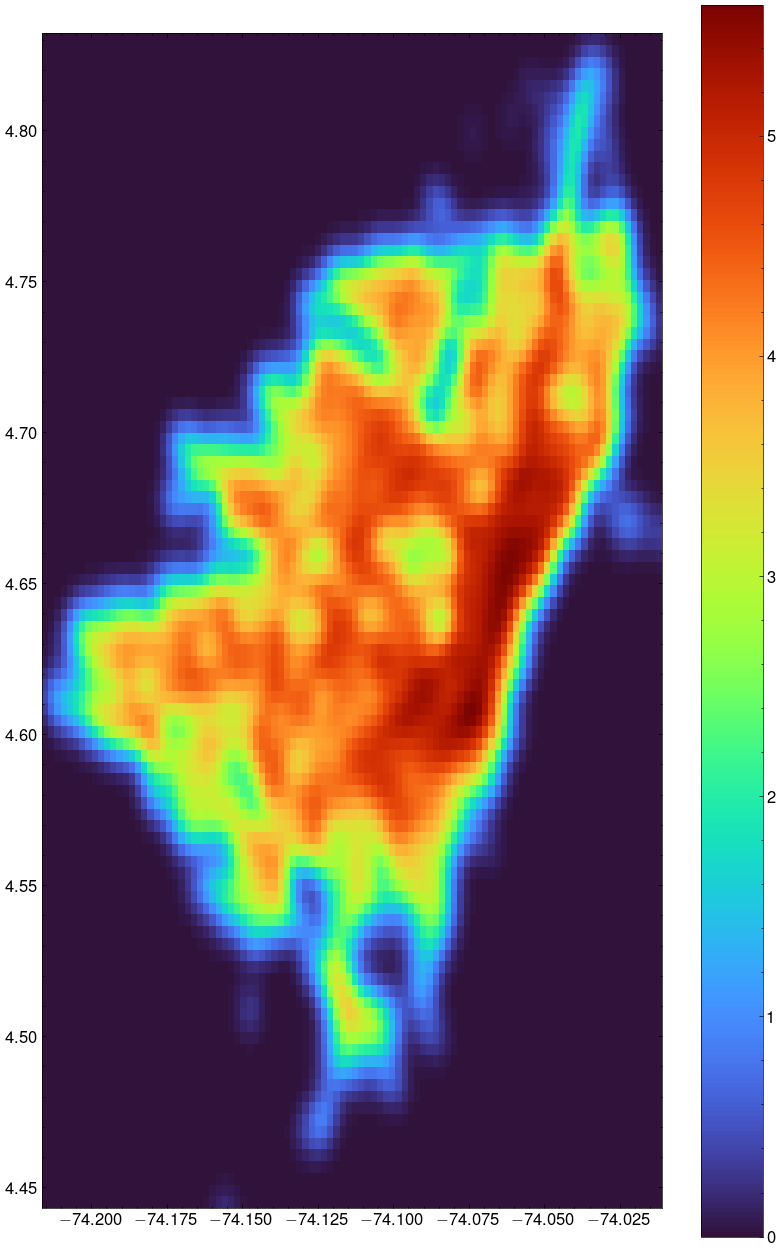

In [6]:
heatmap(gdf, bins=100, smoothing=1.5, cmap="turbo", figsize=(10, 16))

### Approach 1

#### Get Bogota Map from OSMNX and save it

In [ ]:
bogota_osmnx = ox.graph_from_place(
    "Bogota, Colombia",
    network_type="drive",
    truncate_by_edge=True,
)

In [133]:
with open(RAW_DATA_DIR / "bogota_osmnx.pkl", "wb") as f:
    pickle.dump(bogota_osmnx, f)

In [ ]:
tmp_nx = nx.MultiDiGraph()
with open(RAW_DATA_DIR / "bogota_osmnx.pkl", "rb") as f:
    tmp_nx = pickle.load(f)

In [143]:
# Comprobe that both graphs are the same
assert set(nodes := tmp_nx.nodes()) == set(bogota_osmnx.nodes())
assert set(edges := tmp_nx.edges()) == set(bogota_osmnx.edges())

nodes_nx = tmp_nx.nodes(data=True)
nodes_osmnx = bogota_osmnx.nodes(data=True)
edges_nx = tmp_nx.edges(data=True)
edges_osmnx = bogota_osmnx.edges(data=True)

assert all(map(lambda n: nodes_nx[n] == nodes_osmnx[n], nodes))
assert all(
    map(
        lambda e: tmp_nx.get_edge_data(*e) == bogota_osmnx.get_edge_data(*e),
        edges,
    )
)


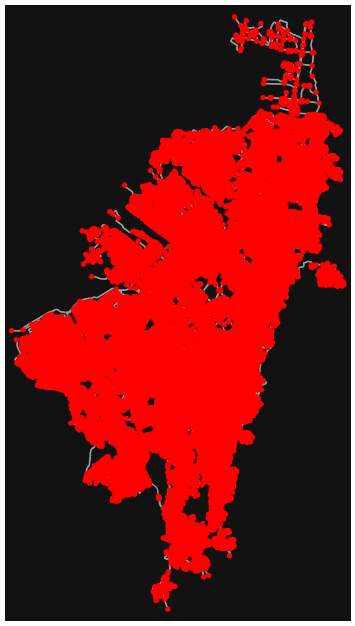

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
ox.plot_graph(bogota_osmnx, node_color="r")

### Magic

In [7]:
bogota_osmnx = nx.MultiDiGraph()
with open(RAW_DATA_DIR / "bogota_osmnx.pkl", "rb") as f:
    bogota_osmnx = pickle.load(f)

In [8]:
print(bogota_osmnx.get_edge_data(253761879, 9644335932))
# list(filter(lambda e: len(bogota_osmnx.get_edge_data(*e)) > 1, bogota_osmnx.edges()))
print(bogota_osmnx.get_edge_data(253761979, 1038356142))

{0: {'osmid': 583975820, 'highway': 'secondary', 'lanes': '3', 'name': 'Avenida Calle 85', 'oneway': True, 'reversed': False, 'length': np.float64(55.64203821530443)}}
{0: {'osmid': [23430457, 88514802, 28224286], 'highway': 'residential', 'lanes': '2', 'name': ['Calle 86A', 'Carrera 19A', 'Carrera 19'], 'oneway': True, 'reversed': False, 'length': np.float64(305.78302598467576), 'geometry': <LINESTRING (-74.057 4.674, -74.057 4.673, -74.057 4.673, -74.056 4.674)>}, 1: {'osmid': 89580906, 'highway': 'residential', 'lanes': '2', 'maxspeed': '30', 'name': 'Calle 87', 'oneway': False, 'reversed': False, 'length': np.float64(66.81258527670072), 'geometry': <LINESTRING (-74.057 4.674, -74.057 4.674, -74.056 4.674)>}}


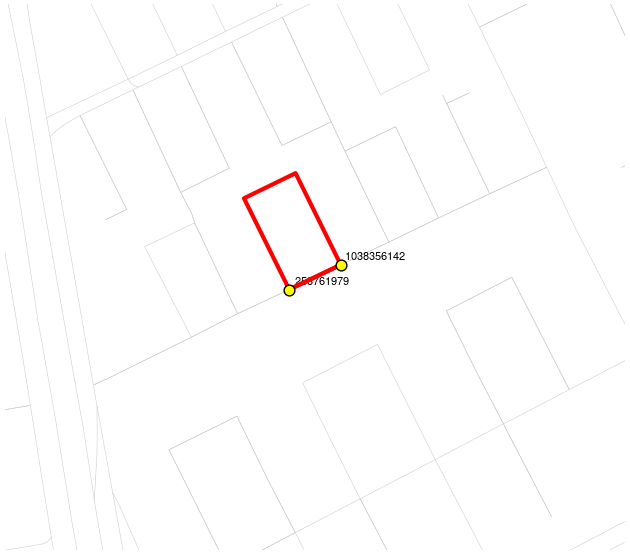

In [9]:
def plot_edge_and_nodes(
    G,
    u,
    v,
    key: str | None = None,
    delta: float | None = None,
    extra_points: list[tuple[float, float]] = None,
):
    # 1) Grafo completo + resaltado
    fig, ax = ox.plot_graph(
        G,
        node_size=0,
        edge_color="#c7c7c7",
        edge_linewidth=0.35,
        bgcolor="white",
        show=False,
        close=False,
    )

    found = False

    for uv in [(u, v), (v, u)]:
        ed = G.get_edge_data(*uv)
        if not ed:
            continue
        found = True
        keys = [key] if key is not None and key in ed else list(ed.keys())

        for k in keys:
            data = ed[k]
            if data.get("geometry") is not None:
                xs, ys = data["geometry"].xy
            else:
                xs = [G.nodes[uv[0]]["x"], G.nodes[uv[1]]["x"]]
                ys = [G.nodes[uv[0]]["y"], G.nodes[uv[1]]["y"]]
            ax.plot(xs, ys, color="red", linewidth=3, zorder=4)

    # Nodos resaltados y etiquetados
    xu, yu = G.nodes[u]["x"], G.nodes[u]["y"]
    xv, yv = G.nodes[v]["x"], G.nodes[v]["y"]
    ax.scatter([xu, xv], [yu, yv], s=60, c="yellow", edgecolors="black", zorder=5)
    if extra_points:
        for point in extra_points:
            ax.scatter(
                [point[0]], [point[1]], s=60, c="yellow", edgecolors="black", zorder=5
            )

    ax.annotate(str(u), (xu, yu), xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.annotate(str(v), (xv, yv), xytext=(4, 4), textcoords="offset points", fontsize=8)

    if delta:
        xlims = [xu - delta, xv + delta]
        if xu > xv:
            xlims = xlims[::-1]

        ylims = [yu - delta, yv + delta]
        if yu > yv:
            ylims = ylims[::-1]

        plt.xlim(xlims)
        plt.ylim(ylims)

    plt.show()

    if not found:
        print("Edge no encontrado en ninguna dirección.")
        return


u, v = 253761979, 1038356142
plot_edge_and_nodes(bogota_osmnx, u, v, delta=0.003 if True else None)

[-74.101699558, 4.655401615]
[{'street_count': 3, 'x': -74.1018399, 'y': 4.6554183},
 {'highway': 'traffic_signals',
  'street_count': 3,
  'x': -74.1005338,
  'y': 4.6570498}]


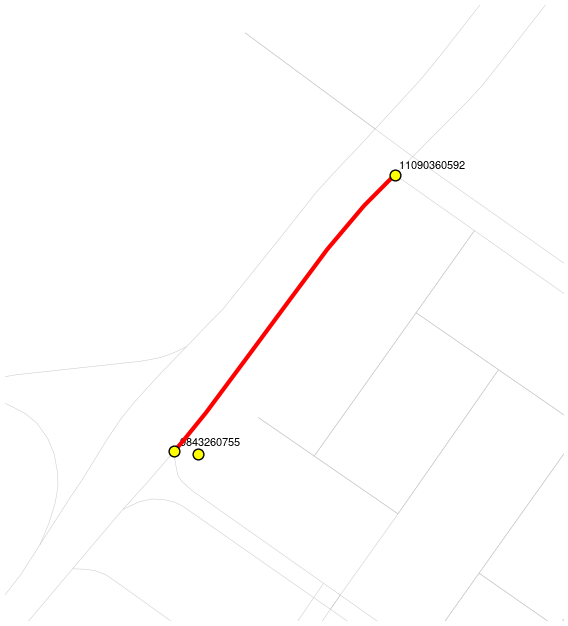

In [10]:
# For each point of accident, get the nearest edge
# Example point
x0, y0 = gdf.loc[0, "geometry"].coords[0]
print([x0, y0])

u, v, _ = ox.distance.nearest_edges(bogota_osmnx, x0, y0)
pprint([bogota_osmnx.nodes[i] for i in (u, v)])

plot_edge_and_nodes(bogota_osmnx, u, v, delta=0.001 if True else None, extra_points=[(x0, y0)])

In [21]:
def get_edge_count_accidents(
    gdf: gpd.GeoDataFrame,
    osmnx_graph: nx.MultiDiGraph,
    inplace: bool = False,
) -> nx.MultiDiGraph | None:
    """
    Vectorized nearest edge counting without multiprocessing.
    """

    if not inplace:
        osmnx_graph = deepcopy(osmnx_graph)

    print("[INFO] Computing nearest edges (vectorized)...")
    xs = gdf.geometry.x.to_numpy()
    ys = gdf.geometry.y.to_numpy()

    uvk = ox.distance.nearest_edges(osmnx_graph, xs, ys).tolist()

    # Normalize return shape across osmnx versions
    # uvk can be (u_arr, v_arr, k_arr) or an (N, 3) ndarray/list
    if isinstance(uvk, tuple) and len(uvk) == 3:
        edges_list = list(zip(uvk[0], uvk[1], uvk[2]))
    else:
        uvk_arr = np.asarray(uvk)
        if uvk_arr.ndim == 2 and uvk_arr.shape[1] == 3:
            edges_list = [tuple(row) for row in uvk_arr]
        else:
            raise RuntimeError("Unexpected return shape from ox.distance.nearest_edges")

    counts = Counter(edges_list)

    print("[INFO] Setting edge attributes in the OSMNX graph...")
    attrs = {
        (u, v, k): {"count_accidents": counts.get((u, v, k), 0)}
        for u, v, k in osmnx_graph.edges(keys=True)
    }
    nx.set_edge_attributes(osmnx_graph, attrs)

    print("[INFO] Done.")
    if not inplace:
        return osmnx_graph

    return None

In [17]:
tmp = get_edge_count_accidents(gdf, bogota_osmnx)
tmp.get_edge_data(253761979, 1038356142)

[INFO] Computing nearest edges (vectorized)...
[INFO] Setting edge attributes in the OSMNX graph...
[INFO] Done.


{0: {'osmid': [23430457, 88514802, 28224286],
  'highway': 'residential',
  'lanes': '2',
  'name': ['Calle 86A', 'Carrera 19A', 'Carrera 19'],
  'oneway': True,
  'reversed': False,
  'length': np.float64(305.78302598467576),
  'geometry': <LINESTRING (-74.057 4.674, -74.057 4.673, -74.057 4.673, -74.056 4.674)>,
  'count_accidents': 2},
 1: {'osmid': 89580906,
  'highway': 'residential',
  'lanes': '2',
  'maxspeed': '30',
  'name': 'Calle 87',
  'oneway': False,
  'reversed': False,
  'length': np.float64(66.81258527670072),
  'geometry': <LINESTRING (-74.057 4.674, -74.057 4.674, -74.056 4.674)>,
  'count_accidents': 1}}

In [32]:
def plot_accident_heatmap_folium(
    G: nx.MultiDiGraph,
    output_path: str | None = None,
    cmap: str = "YlOrRd",
    log_scale: bool = True,
    line_weight_multiplier: float = 2.0,
    min_line_weight: float = 1.0,
    max_line_weight: float = 8.0,
    zoom_start: int = 11,
    tiles: str = "OpenStreetMap",
):
    # Extract accident counts
    edge_data = []
    for u, v, k, data in G.edges(keys=True, data=True):
        count = data.get("count_accidents", 0)
        if count > 0:  # Only include edges with accidents
            edge_data.append(
                {
                    "u": u,
                    "v": v,
                    "k": k,
                    "count": count,
                    "geometry": data.get("geometry"),
                }
            )

    if not edge_data:
        print("[WARNING] No edges with accidents found!")
        return None

    # Get counts for normalization
    counts = np.array([e["count"] for e in edge_data])

    if log_scale:
        counts_normalized = np.log1p(counts)
    else:
        counts_normalized = counts.copy()

    vmin, vmax = counts_normalized.min(), counts_normalized.max()

    print(f"[INFO] Edges with accidents: {len(edge_data)}")
    print(f"[INFO] Min accidents: {counts.min()}")
    print(f"[INFO] Max accidents: {counts.max()}")
    print(f"[INFO] Mean accidents: {counts.mean():.2f}")
    print(f"[INFO] Median accidents: {np.median(counts):.2f}")

    # Create colormap
    colormap = plt.get_cmap(cmap)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Calculate center of the map
    center_lat = np.mean([G.nodes[n]["y"] for n in G.nodes()])
    center_lon = np.mean([G.nodes[n]["x"] for n in G.nodes()])

    # Create map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=zoom_start,
        tiles=tiles,
    )

    # Add edges to map
    for edge in edge_data:
        u, v, k = edge["u"], edge["v"], edge["k"]
        count = edge["count"]
        geometry = edge["geometry"]

        # Get coordinates
        if geometry is not None:
            coords = list(geometry.coords)
            lat_lons = [(lat, lon) for lon, lat in coords]
        else:
            lat_lons = [
                (G.nodes[u]["y"], G.nodes[u]["x"]),
                (G.nodes[v]["y"], G.nodes[v]["x"]),
            ]

        # Normalize count for color
        count_norm = np.log1p(count) if log_scale else count
        color_value = norm(count_norm)
        color = mcolors.rgb2hex(colormap(color_value))

        # Calculate line weight based on count
        weight = min_line_weight + (count / counts.max()) * (
            max_line_weight - min_line_weight
        )

        # Create popup with accident info
        popup_text = f"""
        <b>Accidents:</b> {count}<br>
        <b>Edge:</b> ({u}, {v}, {k})
        """

        # Add line to map
        folium.PolyLine(
            locations=lat_lons,
            color=color,
            weight=weight,
            opacity=0.8,
            popup=folium.Popup(popup_text, max_width=250),
            tooltip=f"{count} accidents",
        ).add_to(m)

    # Add colormap legend
    colormap_obj = cm.ScalarMappable(norm=norm, cmap=colormap)
    colormap_obj.set_array([])

    # Add layer control
    folium.LayerControl().add_to(m)

    # Save or return
    if output_path:
        m.save(output_path)
        print(f"[INFO] Map saved to: {output_path}")

    return m

In [34]:
folium_map = plot_accident_heatmap_folium(
    tmp,
    output_path=str(MAPS_FIGURES_DIR / "accident_heatmap_interactive.html"),
    cmap="YlOrRd",
    log_scale=True,
    line_weight_multiplier=2.0,
    zoom_start=11,
    tiles="OpenStreetMap",
)

[INFO] Edges with accidents: 48075
[INFO] Min accidents: 1
[INFO] Max accidents: 582
[INFO] Mean accidents: 6.86
[INFO] Median accidents: 2.00
[INFO] Map saved to: /home/juand/Documents/vscode/semestre8/ProgramacionCienciaDeDatos/AccidentalRiskAnalysis/figures/maps/accident_heatmap_interactive.html


### Approach 2

To do...